# 2026.10.7(수) 19h~

In [ ]:
import sys
print(sys.executable) # /opt/anaconda3/envs/voice-ai/bin/python

/opt/anaconda3/envs/voice-ai/bin/python


In [ ]:
import tensorflow as tf

sys.path.append('..')
import mat_kor

print("vs code 실습 환경 확인 - 2026.10.7(수) 새벽..")

vs code 실습 환경 확인 - 2026.10.7(수) 새벽..


In [ ]:
print("hello, vs code")

hello, vs code


# CNN Convolution Layer는 왜 활성화 함수로 ReLU를 쓸까?

CNN의 convolution layer에서 ReLU를 쓰는 이유는 크게 네 가지다.

## 1. 비선형성(non-linearity) 도입

Convolution 자체는 선형 연산(가중치 곱셈 + 합)이다. 만약 활성화 함수 없이 conv layer를 계속 쌓으면, 아무리 레이어를 깊게 쌓아도 결국 하나의 선형 변환과 수학적으로 동일해져 버린다(선형 함수의 합성은 여전히 선형). 그러면 복잡한 패턴(모서리 → 질감 → 형태 → 객체)을 계층적으로 학습하는 CNN의 의미가 없어진다. ReLU 같은 비선형 함수가 각 conv layer 사이에 들어가야 레이어를 쌓는 게 실제로 "더 복잡한 함수를 표현할 수 있게" 된다.

## 2. Gradient vanishing 문제 완화

이전에 많이 쓰이던 **sigmoid**나 **tanh**는 입력이 조금만 커지거나 작아져도 미분값(gradient)이 거의 0에 수렴한다(saturating). 레이어가 깊어질수록(CNN은 보통 수십~수백 layer) 이 작은 gradient들이 backpropagation 과정에서 계속 곱해지면서 **gradient vanishing**이 심해져 학습이 거의 멈춘다.

ReLU는 `f(x) = max(0, x)`라서, x>0 구간에서는 **기울기가 항상 1**이다. 그래서 깊은 네트워크에서도 gradient가 잘 전파된다 — 이게 2012년 AlexNet 이후 CNN이 훨씬 깊어질 수 있었던 핵심 이유 중 하나다.

## 3. 계산이 매우 가벼움

sigmoid/tanh는 지수함수(`exp`) 연산이 필요해서 느린데, ReLU는 `max(0, x)` 비교 연산 하나로 끝난다. CNN은 이미지 전체에 걸쳐 수백만 개의 뉴런에 활성화 함수를 적용해야 하므로, 이 연산 비용 차이가 실제 학습/추론 속도에 크게 영향을 준다.

## 4. Sparse activation (희소 활성화) 효과

입력이 음수면 그냥 0을 출력하므로, 한 레이어에서 실제로 "활성화되는"(0이 아닌) 뉴런 비율이 자연스럽게 줄어든다. 이는 특징(feature)들이 서로 덜 얽히게 만들어 표현력에 도움이 되고, 생물학적 뉴런의 동작 방식(자극이 임계치 이하면 발화 안 함)과도 어느 정도 유사하다고 설명된다.

## 참고: output layer는 다름

conv/hidden layer는 `relu`를 쓰지만, 마지막 출력층은 `sigmoid`(이진분류) 또는 `softmax`(다중분류)를 쓴다. 이건 출력을 확률(0~1)로 해석해야 하기 때문이고, hidden layer의 역할(특징 추출)과 output layer의 역할(확률 변환)이 다르기 때문이다.

## 참고: ReLU의 단점

ReLU는 입력이 음수면 gradient가 0이 돼서, 한번 완전히 죽어버린 뉴런(dying ReLU)은 더 이상 학습이 안 될 수 있다. 이를 완화하려고 `LeakyReLU`, `ELU` 같은 변형도 쓰이는데, 기본값으로는 ReLU가 "충분히 좋고 빠르다"는 이유로 가장 널리 쓰인다.


In [1]:
from tensorflow.keras.datasets import mnist # 손글씨 data set
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Input
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

import matplotlib.pyplot as plt
import numpy as np
import os # 디렉토리 생성 등?
import tensorflow as tf

# seed 값 설정
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

2026-10-07 19:12:11.208704: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# 데이터 불러오기
(X_train, Y_train), (X_test, Y_test) = mnist.load_data() # 학습/검증 set 각각의 X/Y
# input_shape=(행, 열, 색상 또는 흑백) 형식. 입력 이미지가 색상이면 3, 흑백이면 1
#즉 CNN을 쓰기 전에는 1차원 배열로 만들어 주었지만 CNN에서는 image 정보를 그대로 살림  지정.

In [3]:
X_train.shape # 학습

(60000, 28, 28)

In [4]:
X_test.shape # 검증

(10000, 28, 28)

In [ ]:
# input_shape=(행, 열, 색상 또는 흑백) 형식. 입력 이미지가 색상이면 3, 흑백이면 1
#즉 CNN을 쓰기 전에는 1차원 배열로 만들어 주었지만 CNN에서는 image 정보를 그대로 살림  지정.
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255 # 32비트 실수? -> 0~1 사이로 정규화
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255
Y_train = tf.keras.utils.to_categorical(Y_train) # 어느 자리가 1인지에 따라 카테고리로 분류
Y_test = tf.keras.utils.to_categorical(Y_test)

# 컨볼루션 신경망 설정
model = Sequential() # sequential로 model 객체 만듦
#model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(28, 28, 1), activation='relu'))
model.add(Input(shape = (28, 28, 1)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu')) # 32개의 필터를 사용한다, 특징 맵 뽑아내기 위한 필터 3*3 사용, conv2D를 통해 기본적인 특성(선, 경계, 방향성 등) 찾을 때 비선형성 있으면 relu 사용?
model.add(Conv2D(64, (3, 3), activation='relu')) # 64개의 필터 적용, 조금 전 conv2d에서보다 조금 더 큰 특징들 뽑아냄
model.add(MaxPooling2D(pool_size=2)) # 2차원 24*24 -> 12*12, 덜 선명하지만 학습의 속도 개선
model.add(Dropout(0.25)) # 과적합 방지, 없다고 봐도 무방, 왜냐하면 early stopping으로 있다가 과적합 잡을 거라서..
model.add(Flatten()) # 1차원으로 펼침
# 이상 이미지 특징 -> 이하 이미지 분류
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))


In [7]:
model.compile(loss='categorical_crossentropy', # 다항 분류니까
              optimizer='adam',
              metrics=['accuracy'])

# 모델 최적화 설정
MODEL_DIR = '../models/model_CNN_M/'
if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

modelpath="../models/model_CNN_M/{epoch:02d}-{val_loss:.4f}.keras"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=1, # 진행 상태 표시 <- verbose=1
                               save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10)

# 모델의 실행
history = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=30,    
         batch_size=200, verbose=3, callbacks=[early_stopping_callback,checkpointer])


Epoch 1/30



Epoch 1: val_loss improved from None to 0.04291, saving model to ../models/model_CNN_M/01-0.0429.keras

Epoch 1: finished saving model to ../models/model_CNN_M/01-0.0429.keras
Epoch 2/30

Epoch 2: val_loss improved from 0.04291 to 0.03289, saving model to ../models/model_CNN_M/02-0.0329.keras

Epoch 2: finished saving model to ../models/model_CNN_M/02-0.0329.keras
Epoch 3/30

Epoch 3: val_loss improved from 0.03289 to 0.03174, saving model to ../models/model_CNN_M/03-0.0317.keras

Epoch 3: finished saving model to ../models/model_CNN_M/03-0.0317.keras
Epoch 4/30

Epoch 4: val_loss improved from 0.03174 to 0.02876, saving model to ../models/model_CNN_M/04-0.0288.keras

Epoch 4: finished saving model to ../models/model_CNN_M/04-0.0288.keras
Epoch 5/30

Epoch 5: val_loss improved from 0.02876 to 0.02748, saving model to ../models/model_CNN_M/05-0.0275.keras

Epoch 5: finished saving model to ../models/model_CNN_M/05-0.0275.keras
Epoch 6/30

Epoch 6: val_loss did not improve from 0.02748


313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.9923 - loss: 0.0317

 Test Accuracy: 0.9923


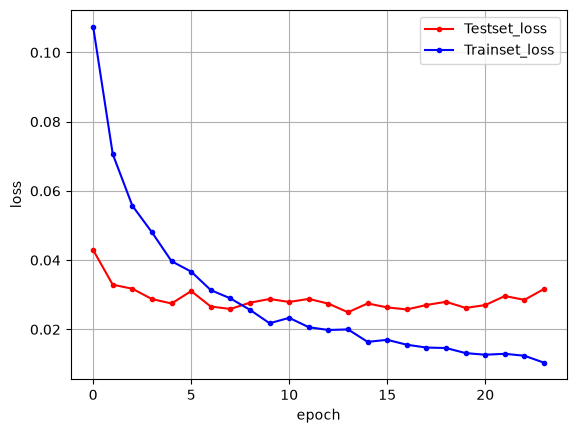

In [8]:
# 테스트 정확도 출력 
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, Y_test) [1]))

# 테스트셋의 오차
y_vloss = history.history['val_loss']

# 학습셋의 오차
y_loss = history.history['loss']

# 그래프로 표현
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()
